# S&P 500 Momentum Strategy

## Research Question

Does a portfolio of S&P 500 stocks with strong prior
12-to-1-month returns outperform the S&P 500 benchmark?

## Hypothesis

Stocks that have performed strongly over the previous
12-to-1-month period will, on average, generate higher
subsequent returns than stocks with weak momentum.

## Initial Strategy

- Universe: S&P 500 constituents
- Signal: 12-month return excluding the most recent month
- Portfolio: Top 10% of stocks
- Rebalancing: Monthly
- Benchmark: SPY

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import yfinance as yf

print("environment is working!")

environment is working!


In [3]:
spy = yf.Ticker("SPY")

data = spy.history(
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2010-01-04 00:00:00-05:00,83.654313,84.413653,83.014082,84.368988,118944600,0.0,0.0,0.0
2010-01-05 00:00:00-05:00,84.316864,84.629533,84.011635,84.592308,111579900,0.0,0.0,0.0
2010-01-06 00:00:00-05:00,84.510400,84.860294,84.443402,84.651848,116074400,0.0,0.0,0.0
2010-01-07 00:00:00-05:00,84.495518,85.113417,84.257293,85.009193,131091100,0.0,0.0,0.0
2010-01-08 00:00:00-05:00,84.785862,85.329316,84.614641,85.292091,126402800,0.0,0.0,0.0


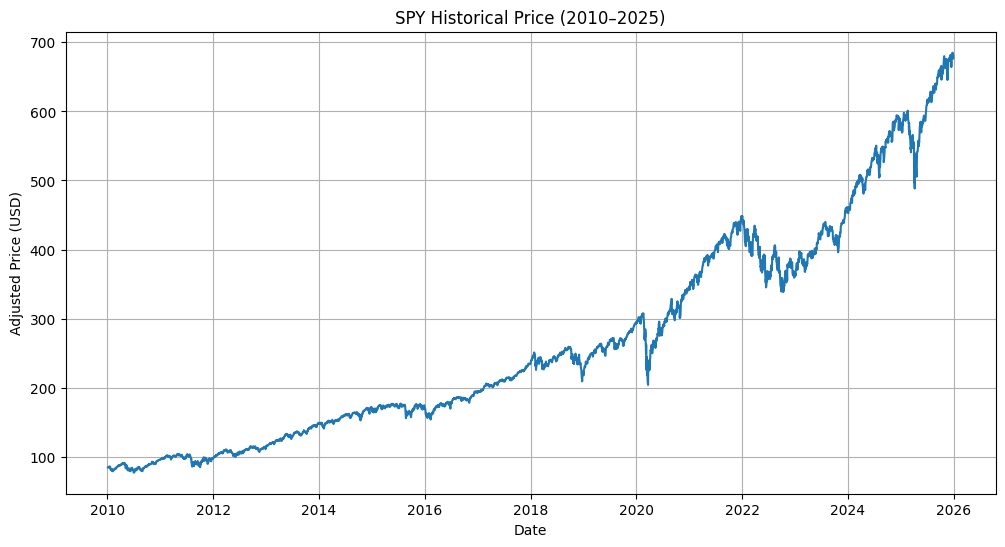

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data["Close"])

plt.title("SPY Historical Price (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Adjusted Price (USD)")
plt.grid(True)

plt.show()

In [5]:
data["Return"] = data["Close"].pct_change()

data[["Close", "Return"]].head(10)

,Close,Return
Date,,
2010-01-04 00:00:00-05:00,84.368988,NaN
2010-01-05 00:00:00-05:00,84.592308,0.002647
2010-01-06 00:00:00-05:00,84.651848,0.000704
2010-01-07 00:00:00-05:00,85.009193,0.004221
2010-01-08 00:00:00-05:00,85.292091,0.003328
2010-01-11 00:00:00-05:00,85.411232,0.001397
2010-01-12 00:00:00-05:00,84.614632,-0.009327
2010-01-13 00:00:00-05:00,85.329323,0.008446
2010-01-14 00:00:00-05:00,85.560120,0.002705


In [6]:
cumulative_return = (1 + data["Return"]).cumprod() - 1

cumulative_return.iloc[-1]

np.float64(7.0199493381147455)

In [7]:
print(f"Cumulative return: {cumulative_return.iloc[-1]:.2%}")

Cumulative return: 701.99%


In [8]:
years = (data.index[-1] - data.index[0]).days / 365.25

cagr = (1 + cumulative_return.iloc[-1]) ** (1 / years) - 1

print(f"Investment period: {years:.2f} years")
print(f"CAGR: {cagr:.2%}")

Investment period: 15.99 years
CAGR: 13.91%


In [11]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

response = requests.get(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

print(response.status_code)

200


In [12]:
html = response.text

sp500_table = pd.read_html(html)

sp500 = sp500_table[0]

sp500.head()

/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/2116991359.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(html)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [13]:
print(f"Number of constituents: {len(sp500)}")

Number of constituents: 503


In [14]:
tickers = sp500["Symbol"].tolist()

tickers = [ticker.replace(".", "-") for ticker in tickers]

print(tickers[:20])

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']


In [15]:
test_tickers = tickers[:5]

print(test_tickers)

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']


In [16]:
test_data = yf.download(
    test_tickers,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

test_data.head()

Price      Close                                            High             \
Ticker      ABBV        ABT        ACN       AOS        MMM ABBV        ABT   
Date                                                                          
2010-01-04   NaN  18.078796  30.856331  5.721533  42.374981  NaN  18.111994   
2010-01-05   NaN  17.932739  31.047031  5.648426  42.109539  NaN  18.082123   
2010-01-06   NaN  18.032330  31.377085  5.650991  42.706741  NaN  18.055566   
2010-01-07   NaN  18.181707  31.347752  5.667665  42.737373  NaN  18.185026   
2010-01-08   NaN  18.274660  31.223070  5.751030  43.038517  NaN  18.341052   

Price                                       ... Open                        \
Ticker            ACN       AOS        MMM  ... ABBV        ABT        ACN   
Date                                        ...                              
2010-01-04  30.951680  5.756163  42.594459  ...  NaN  17.989166  30.452933   
2010-01-05  31.135045  5.718967  42.482144  ...  NaN  18.082123  30.878335   
2010-01-06  31.465101  5.698447  43.181433  ...  NaN  17.906182  30.871004   
2010-01-07  31.465104  5.713838  42.752687  ...  NaN  18.029003  31.171722   
2010-01-08  31.582463  5.760008  43.038517  ...  NaN  18.178390  31.179062   

Price                           Volume                                       
Ticker           AOS        MMM   ABBV       ABT      ACN      AOS      MMM  
Date                                                                         
2010-01-04  5.613798  42.410708    NaN  10829095  3650100  1104600  3640265  
2010-01-05  5.718967  42.262662    NaN  10562109  2613000  1207200  3405012  
2010-01-06  5.644579  42.813932    NaN  11401417  5772100   663000  6301126  
2010-01-07  5.661253  42.528100    NaN  12857232  4022900   564000  5346240  
2010-01-08  5.642012  42.716953    NaN  12148604  5069700   504600  4073337  

[5 rows x 25 columns]

In [19]:
sp500[["Symbol", "Security", "GICS Sector"]].to_csv(
    "../data/sp500_constituents.csv",
    index=False
)

In [20]:
prices = yf.download(
    tickers,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=True,
    threads=True
)

[***********           23%                       ]  117 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1767243600")
[*************         28%                       ]  142 of 503 completedFailed to get ticker 'HOOD' reason: Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[**********************47%                       ]  238 of 503 completed$HONA: possibly delisted; no price data found  (1d 2010-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1767243600")
[**********************86%****************       ]  432 of 503 completedFailed to get ticker 'CHRW' reason: Failed to perform, curl: (28) Connection timed out after 10001 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[***********

In [21]:
prices.head()

Price      Adj Close           Close                                           \
Ticker          FDXF HONA          A      AAPL ABBV ABNB        ABT      ACGL   
Date                                                                            
2010-01-04       NaN  NaN  19.772951  6.400959  NaN  NaN  18.078800  7.601905   
2010-01-05       NaN  NaN  19.558168  6.412027  NaN  NaN  17.932735  7.576549   
2010-01-06       NaN  NaN  19.488674  6.310034  NaN  NaN  18.032328  7.543795   
2010-01-07       NaN  NaN  19.463415  6.298369  NaN  NaN  18.181704  7.499420   
2010-01-08       NaN  NaN  19.457098  6.340243  NaN  NaN  18.274662  7.484628   

Price                             ...   Volume                              \
Ticker            ACN       ADBE  ...       WY     WYNN      XEL       XOM   
Date                              ...                                        
2010-01-04  30.856323  37.090000  ...  1832400  4741400  2670400  27809100   
2010-01-05  31.047031  37.700001  ...  1724500  5644300  4321400  30174700   
2010-01-06  31.377081  37.619999  ...  2254400  2738800  2164500  35044700   
2010-01-07  31.347742  36.889999  ...  1420700  2388500  3041700  27192100   
2010-01-08  31.223057  36.689999  ...  1310000  1539800  1599100  24891800   

Price                                             
Ticker     XYL XYZ      YUM      ZBH    ZBRA ZTS  
Date                                              
2010-01-04 NaN NaN  2962274   805872  168800 NaN  
2010-01-05 NaN NaN  3298757  1769643  168800 NaN  
2010-01-06 NaN NaN  4178981  1315619  385300 NaN  
2010-01-07 NaN NaN  2452472  1734005  183600 NaN  
2010-01-08 NaN NaN  3772392  2213985  266500 NaN  

[5 rows x 2517 columns]

In [22]:
prices.to_pickle("../data/raw_prices.pkl")

In [24]:
import os

os.path.exists("../data/sp500_constituents.csv")

True

In [25]:
os.path.exists("../data/sp500_constituents.csv")

True

In [28]:
prices.columns

MultiIndex([('Adj Close', 'FDXF'),
            ('Adj Close', 'HONA'),
            (    'Close',    'A'),
            (    'Close', 'AAPL'),
            (    'Close', 'ABBV'),
            (    'Close', 'ABNB'),
            (    'Close',  'ABT'),
            (    'Close', 'ACGL'),
            (    'Close',  'ACN'),
            (    'Close', 'ADBE'),
            ...
            (   'Volume',   'WY'),
            (   'Volume', 'WYNN'),
            (   'Volume',  'XEL'),
            (   'Volume',  'XOM'),
            (   'Volume',  'XYL'),
            (   'Volume',  'XYZ'),
            (   'Volume',  'YUM'),
            (   'Volume',  'ZBH'),
            (   'Volume', 'ZBRA'),
            (   'Volume',  'ZTS')],
           names=['Price', 'Ticker'], length=2517)

In [29]:
close_prices = prices["Close"].copy()

close_prices.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,19.772951,6.400959,NaN,NaN,18.078800,7.601905,30.856323,37.090000,21.703718,20.029284,...,9.157348,40.493725,11.901503,37.136814,NaN,NaN,18.252983,51.313568,28.670000,NaN
2010-01-05,19.558168,6.412027,NaN,NaN,17.932735,7.576549,31.047031,37.700001,21.669451,20.137474,...,9.351746,42.956535,11.760360,37.281807,NaN,NaN,18.190565,52.937973,28.620001,NaN
2010-01-06,19.488674,6.310034,NaN,NaN,18.032328,7.543795,31.377081,37.619999,21.628328,20.086569,...,9.248343,42.393063,11.782941,37.604038,NaN,NaN,18.060520,52.920864,28.400000,NaN
2010-01-07,19.463415,6.298369,NaN,NaN,18.181704,7.499420,31.347742,36.889999,21.457005,19.876528,...,9.206983,43.298409,11.732127,37.485897,NaN,NaN,18.055311,54.134872,27.690001,NaN
2010-01-08,19.457098,6.340243,NaN,NaN,18.274662,7.484628,31.223057,36.689999,21.580368,19.628311,...,9.122194,42.988194,11.737773,37.335510,NaN,NaN,18.060520,52.997807,27.600000,NaN


In [30]:
monthly_prices = close_prices.resample("ME").last()

monthly_prices.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-31,17.707214,5.744446,NaN,NaN,17.702562,7.558587,30.064213,32.299999,18.475914,19.074594,...,8.261479,39.176857,11.732127,34.601955,NaN,NaN,17.899675,48.150276,26.100000,NaN
2010-02-28,19.874025,6.120108,NaN,NaN,18.150642,7.816386,29.316078,34.650002,20.038422,18.780991,...,8.365005,40.246811,11.749068,35.135792,NaN,NaN,17.643282,49.013763,28.570000,NaN
2010-03-31,21.724979,7.028762,NaN,NaN,17.615620,8.056224,30.768324,35.369999,19.884848,18.486736,...,9.373359,48.008739,12.107219,36.206089,NaN,NaN,20.055378,50.612503,29.600000,NaN
2010-04-30,22.906298,7.809105,NaN,NaN,17.251472,7.985435,32.288784,33.599998,20.650719,17.872646,...,10.263584,55.865639,12.421324,36.633121,NaN,NaN,22.309210,52.074471,29.049999,NaN
2010-05-31,20.442574,7.683185,NaN,NaN,16.037523,7.767785,27.760656,32.080002,20.281979,16.254438,...,8.825189,53.278290,11.701741,32.903641,NaN,NaN,21.536114,47.816864,27.500000,NaN


In [31]:
momentum = monthly_prices.shift(1) / monthly_prices.shift(12) - 1

momentum.head(15)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
latest_momentum = momentum.iloc[-1].dropna().sort_values(ascending=False)

latest_momentum.head(10)

Ticker
BE      3.918505
LITE    2.873258
WDC     2.634751
HOOD    2.448471
STX     2.259428
ECHO    2.200437
MU      1.817957
NEM     1.478997
CIEN    1.407853
FIX     1.311937
Name: 2025-12-31 00:00:00, dtype: float64

In [33]:
momentum_rank = momentum.rank(
    axis=1,
    ascending=False,
    pct=True
)

momentum_rank.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,0.841683,0.731463,0.597194,0.414830,0.400802,0.859719,0.863727,0.981964,0.633267,0.721443,...,0.819639,0.126253,0.266533,0.635271,0.519038,0.344689,0.484970,0.855711,0.619238,0.849699
2025-09-30,0.821643,0.619238,0.452906,0.569138,0.326653,0.813627,0.933868,0.957916,0.444890,0.476954,...,0.905812,0.162325,0.394790,0.607214,0.517034,0.322645,0.513026,0.637275,0.819639,0.873747
2025-10-31,0.645291,0.434870,0.370741,0.787575,0.332665,0.685371,0.949900,0.945892,0.456914,0.446894,...,0.891784,0.184369,0.288577,0.637275,0.310621,0.639279,0.352705,0.749499,0.919840,0.883768
2025-11-30,0.400802,0.292585,0.202405,0.605210,0.412826,0.755511,0.927856,0.959920,0.358717,0.294589,...,0.911824,0.174349,0.274549,0.503006,0.218437,0.749499,0.476954,0.657315,0.955912,0.787575
2025-12-31,0.416834,0.458918,0.216433,0.819639,0.398798,0.623246,0.947896,0.949900,0.272545,0.288577,...,0.893788,0.108216,0.276553,0.462926,0.324649,0.917836,0.402806,0.761523,0.971944,0.911824


In [34]:
top_10 = momentum_rank <= 0.10

top_10.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025-09-30,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025-10-31,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025-11-30,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025-12-31,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
stocks_selected = top_10.sum(axis=1)

stocks_selected.tail(10)

Date
2025-03-31    49
2025-04-30    49
2025-05-31    49
2025-06-30    49
2025-07-31    49
2025-08-31    49
2025-09-30    49
2025-10-31    49
2025-11-30    49
2025-12-31    49
Freq: ME, dtype: int64

In [36]:
weights = top_10.astype(float)

weights = weights.div(
    weights.sum(axis=1),
    axis=0
)

weights.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-11-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
weights.sum(axis=1).tail()

Date
2025-08-31    1.0
2025-09-30    1.0
2025-10-31    1.0
2025-11-30    1.0
2025-12-31    1.0
Freq: ME, dtype: float64

In [38]:
monthly_returns = monthly_prices.pct_change()

monthly_returns.tail()

/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/2062449731.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,0.094504,0.119639,0.113110,-0.014198,0.051272,0.063560,-0.026694,-0.002768,0.118773,0.166064,...,0.041160,0.165186,-0.014297,0.033263,-0.018444,0.030805,0.019563,0.157665,-0.064686,0.072776
2025-09-30,0.023458,0.096881,0.100475,-0.069792,0.009649,-0.008740,-0.051429,-0.011074,-0.018456,-0.046296,...,-0.041747,0.011992,0.122830,-0.013475,0.041961,-0.092541,0.039245,-0.069358,-0.062853,-0.064450
2025-10-31,0.140319,0.061815,-0.051516,0.042168,-0.072945,-0.048716,0.014193,-0.035266,-0.047090,0.013224,...,-0.072207,-0.072347,0.006448,0.014279,0.022712,0.050782,-0.090724,0.020914,-0.093922,-0.011812
2025-11-30,0.048784,0.032364,0.044304,-0.075470,0.042712,0.088171,-0.000400,-0.059299,0.133302,0.011926,...,-0.025151,0.083679,0.011581,0.022507,-0.064847,-0.120358,0.108530,-0.030231,-0.061281,-0.110417
2025-12-31,-0.113550,-0.025067,0.003470,0.160099,-0.028006,0.021295,0.073200,0.093275,0.025695,-0.053507,...,0.066637,-0.064890,-0.093532,0.038130,-0.031919,-0.025599,-0.007921,-0.075482,-0.039288,-0.018412


In [40]:
strategy_returns = (
    weights * monthly_returns.shift(-1)
).sum(axis=1)

strategy_returns = strategy_returns.dropna()

strategy_returns.tail()

Date
2025-08-31    0.134452
2025-09-30    0.036018
2025-10-31   -0.014369
2025-11-30    0.020587
2025-12-31    0.000000
Freq: ME, dtype: float64

In [41]:
strategy_cumulative = (1 + strategy_returns).cumprod()

strategy_years = (
    strategy_cumulative.index[-1] - strategy_cumulative.index[0]
).days / 365.25

strategy_cagr = (
    strategy_cumulative.iloc[-1] ** (1 / strategy_years)
) - 1

print(f"Strategy period: {strategy_years:.2f} years")
print(f"Strategy CAGR: {strategy_cagr:.2%}")

Strategy period: 15.92 years
Strategy CAGR: 21.91%


In [42]:
annualized_vol = strategy_returns.std() * np.sqrt(12)

sharpe_ratio = (
    strategy_returns.mean() / strategy_returns.std()
) * np.sqrt(12)

print(f"Annualized volatility: {annualized_vol:.2%}")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")

Annualized volatility: 17.88%
Sharpe ratio: 1.20


In [43]:
strategy_cumulative = (1 + strategy_returns).cumprod()

running_max = strategy_cumulative.cummax()

drawdown = (
    strategy_cumulative / running_max
) - 1

max_drawdown = drawdown.min()

print(f"Maximum drawdown: {max_drawdown:.2%}")

Maximum drawdown: -21.56%


In [46]:
spy_monthly = data["Close"].resample("ME").last()

spy_returns = spy_monthly.pct_change()

common_dates = strategy_returns.index.intersection(
    spy_returns.index
)

strategy_aligned = strategy_returns.loc[common_dates]
spy_aligned = spy_returns.loc[common_dates]

spy_aligned.tail()

Series([], Freq: ME, Name: Close, dtype: float64)

In [48]:
print("Strategy dates:")
print(strategy_returns.index[:3])
print(strategy_returns.index[-3:])

print("\nSPY dates:")
print(spy_returns.index[:3])
print(spy_returns.index[-3:])

print("\nNumber of common dates:")
print(len(strategy_returns.index.intersection(spy_returns.index)))

Strategy dates:
DatetimeIndex(['2010-01-31', '2010-02-28', '2010-03-31'], dtype='datetime64[ns]', name='Date', freq='ME')
DatetimeIndex(['2025-10-31', '2025-11-30', '2025-12-31'], dtype='datetime64[ns]', name='Date', freq='ME')

SPY dates:
DatetimeIndex(['2010-01-31 00:00:00-05:00', '2010-02-28 00:00:00-05:00',
               '2010-03-31 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', freq='ME')
DatetimeIndex(['2025-10-31 00:00:00-04:00', '2025-11-30 00:00:00-05:00',
               '2025-12-31 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', freq='ME')

Number of common dates:
0


In [49]:
spy_returns.index = spy_returns.index.tz_localize(None)

spy_returns.head()

Date
2010-01-31         NaN
2010-02-28    0.031194
2010-03-31    0.060880
2010-04-30    0.015470
2010-05-31   -0.079455
Name: Close, dtype: float64

In [50]:
common_dates = strategy_returns.index.intersection(
    spy_returns.index
)

print(f"Common dates: {len(common_dates)}")
print(common_dates[:3])

Common dates: 192
DatetimeIndex(['2010-01-31', '2010-02-28', '2010-03-31'], dtype='datetime64[ns]', name='Date', freq='ME')


In [51]:
strategy_aligned = strategy_returns.loc[common_dates]
spy_aligned = spy_returns.loc[common_dates]

spy_aligned.tail()

Date
2025-08-31    0.020519
2025-09-30    0.035620
2025-10-31    0.023837
2025-11-30    0.001950
2025-12-31    0.000797
Name: Close, dtype: float64

In [52]:
print(f"Common dates: {len(common_dates)}")

Common dates: 192


In [53]:
spy_cumulative = (1 + spy_aligned).cumprod()

spy_years = (
    spy_cumulative.index[-1] - spy_cumulative.index[0]
).days / 365.25

spy_cagr = (
    spy_cumulative.iloc[-1] ** (1 / spy_years)
) - 1

spy_volatility = spy_aligned.std() * np.sqrt(12)

spy_sharpe = (
    spy_aligned.mean() / spy_aligned.std()
) * np.sqrt(12)

spy_drawdown = (
    spy_cumulative / spy_cumulative.cummax()
) - 1

spy_max_drawdown = spy_drawdown.min()

print(f"SPY period: {spy_years:.2f} years")
print(f"SPY CAGR: {spy_cagr:.2%}")
print(f"SPY annualized volatility: {spy_volatility:.2%}")
print(f"SPY Sharpe ratio: {spy_sharpe:.2f}")
print(f"SPY maximum drawdown: {spy_max_drawdown:.2%}")

SPY period: 15.92 years
SPY CAGR: 14.36%
SPY annualized volatility: 14.32%
SPY Sharpe ratio: 1.01
SPY maximum drawdown: -23.93%


In [54]:
monthly_turnover = (
    weights.diff().abs().sum(axis=1) / 2
)

monthly_turnover = monthly_turnover.dropna()

print(f"Average monthly turnover: {monthly_turnover.mean():.2%}")
print(f"Average annual turnover: {monthly_turnover.mean() * 12:.2%}")

Average monthly turnover: 25.95%
Average annual turnover: 311.43%


In [55]:
valid_signal = weights.sum(axis=1) > 0

next_month_available = monthly_returns.shift(-1).notna().any(axis=1)

valid_backtest = valid_signal & next_month_available

strategy_returns_clean = (
    weights.loc[valid_backtest]
    * monthly_returns.shift(-1).loc[valid_backtest]
).sum(axis=1)

print("First strategy return:", strategy_returns_clean.index[0])
print("Last strategy return:", strategy_returns_clean.index[-1])
print("Number of months:", len(strategy_returns_clean))

First strategy return: 2011-01-31 00:00:00
Last strategy return: 2025-11-30 00:00:00
Number of months: 179


In [56]:
strategy_cumulative_clean = (1 + strategy_returns_clean).cumprod()

strategy_years_clean = (
    strategy_cumulative_clean.index[-1]
    - strategy_cumulative_clean.index[0]
).days / 365.25

strategy_cagr_clean = (
    strategy_cumulative_clean.iloc[-1] ** (1 / strategy_years_clean)
) - 1

strategy_vol_clean = (
    strategy_returns_clean.std() * np.sqrt(12)
)

strategy_sharpe_clean = (
    strategy_returns_clean.mean()
    / strategy_returns_clean.std()
) * np.sqrt(12)

running_max_clean = strategy_cumulative_clean.cummax()
drawdown_clean = (
    strategy_cumulative_clean / running_max_clean
) - 1

strategy_max_drawdown_clean = drawdown_clean.min()

print(f"CAGR: {strategy_cagr_clean:.2%}")
print(f"Annualized volatility: {strategy_vol_clean:.2%}")
print(f"Sharpe ratio: {strategy_sharpe_clean:.2f}")
print(f"Maximum drawdown: {strategy_max_drawdown_clean:.2%}")

CAGR: 23.69%
Annualized volatility: 18.44%
Sharpe ratio: 1.25
Maximum drawdown: -21.56%


In [57]:
common_dates_clean = strategy_returns_clean.index.intersection(
    spy_returns.index
)

strategy_aligned_clean = strategy_returns_clean.loc[common_dates_clean]
spy_aligned_clean = spy_returns.loc[common_dates_clean]

spy_cumulative_clean = (1 + spy_aligned_clean).cumprod()

spy_years_clean = (
    spy_cumulative_clean.index[-1]
    - spy_cumulative_clean.index[0]
).days / 365.25

spy_cagr_clean = (
    spy_cumulative_clean.iloc[-1] ** (1 / spy_years_clean)
) - 1

spy_vol_clean = (
    spy_aligned_clean.std() * np.sqrt(12)
)

spy_sharpe_clean = (
    spy_aligned_clean.mean()
    / spy_aligned_clean.std()
) * np.sqrt(12)

spy_running_max_clean = spy_cumulative_clean.cummax()

spy_drawdown_clean = (
    spy_cumulative_clean
    / spy_running_max_clean
) - 1

spy_max_drawdown_clean = spy_drawdown_clean.min()

print(f"SPY CAGR: {spy_cagr_clean:.2%}")
print(f"SPY annualized volatility: {spy_vol_clean:.2%}")
print(f"SPY Sharpe ratio: {spy_sharpe_clean:.2f}")
print(f"SPY maximum drawdown: {spy_max_drawdown_clean:.2%}")

SPY CAGR: 14.11%
SPY annualized volatility: 14.06%
SPY Sharpe ratio: 1.01
SPY maximum drawdown: -23.93%


In [58]:
turnover_clean = monthly_turnover.loc[
    strategy_returns_clean.index
]

costs_bps = [5, 10, 20, 50]

for cost_bps in costs_bps:
    
    cost_rate = cost_bps / 10_000
    
    net_returns = (
        strategy_returns_clean
        - turnover_clean * cost_rate
    )
    
    net_cumulative = (1 + net_returns).cumprod()
    
    net_years = (
        net_cumulative.index[-1]
        - net_cumulative.index[0]
    ).days / 365.25
    
    net_cagr = (
        net_cumulative.iloc[-1] ** (1 / net_years)
    ) - 1
    
    net_vol = net_returns.std() * np.sqrt(12)
    
    net_sharpe = (
        net_returns.mean()
        / net_returns.std()
    ) * np.sqrt(12)
    
    net_running_max = net_cumulative.cummax()
    net_drawdown = (
        net_cumulative / net_running_max
    ) - 1
    
    net_max_drawdown = net_drawdown.min()
    
    print(f"\nTransaction cost: {cost_bps} bps")
    print(f"Net CAGR: {net_cagr:.2%}")
    print(f"Net volatility: {net_vol:.2%}")
    print(f"Net Sharpe: {net_sharpe:.2f}")
    print(f"Net max drawdown: {net_max_drawdown:.2%}")


Transaction cost: 5 bps
Net CAGR: 23.49%
Net volatility: 18.45%
Net Sharpe: 1.24
Net max drawdown: -21.60%

Transaction cost: 10 bps
Net CAGR: 23.28%
Net volatility: 18.45%
Net Sharpe: 1.23
Net max drawdown: -21.64%

Transaction cost: 20 bps
Net CAGR: 22.88%
Net volatility: 18.45%
Net Sharpe: 1.21
Net max drawdown: -21.72%

Transaction cost: 50 bps
Net CAGR: 21.67%
Net volatility: 18.47%
Net Sharpe: 1.16
Net max drawdown: -21.96%


In [59]:
momentum_6_1 = (
    monthly_prices.shift(1)
    / monthly_prices.shift(6)
    - 1
)

momentum_rank_6_1 = momentum_6_1.rank(
    axis=1,
    ascending=False,
    pct=True
)

top_10_6_1 = momentum_rank_6_1 <= 0.10

weights_6_1 = top_10_6_1.astype(float)

weights_6_1 = weights_6_1.div(
    weights_6_1.sum(axis=1),
    axis=0
)

In [63]:
strategy_returns_6_1 = (
    weights_6_1
    * monthly_returns.shift(-1)
).sum(axis=1)

# Keep only months with a valid portfolio
valid_6_1 = (
    (weights_6_1.sum(axis=1) > 0)
    & monthly_returns.shift(-1).notna().any(axis=1)
)

strategy_returns_6_1 = strategy_returns_6_1.loc[valid_6_1]

In [64]:
cumulative_6_1 = (1 + strategy_returns_6_1).cumprod()

years_6_1 = (
    cumulative_6_1.index[-1]
    - cumulative_6_1.index[0]
).days / 365.25

cagr_6_1 = (
    cumulative_6_1.iloc[-1] ** (1 / years_6_1)
) - 1

vol_6_1 = strategy_returns_6_1.std() * np.sqrt(12)

sharpe_6_1 = (
    strategy_returns_6_1.mean()
    / strategy_returns_6_1.std()
) * np.sqrt(12)

drawdown_6_1 = (
    cumulative_6_1 / cumulative_6_1.cummax()
) - 1

max_dd_6_1 = drawdown_6_1.min()

print(f"6_1 CAGR: {cagr_6_1:.2%}")
print(f"6_1 volatility: {vol_6_1:.2%}")
print(f"6_1 Sharpe: {sharpe_6_1:.2f}")
print(f"6_1 max drawdown: {max_dd_6_1:.2%}")

6_1 CAGR: 25.27%
6_1 volatility: 18.75%
6_1 Sharpe: 1.30
6_1 max drawdown: -21.87%


In [65]:
momentum_12_2 = (
    monthly_prices.shift(2)
    / monthly_prices.shift(12)
    - 1
)

momentum_rank_12_2 = momentum_12_2.rank(
    axis=1,
    ascending=False,
    pct=True
)

top_10_12_2 = momentum_rank_12_2 <= 0.10

weights_12_2 = top_10_12_2.astype(float)

weights_12_2 = weights_12_2.div(
    weights_12_2.sum(axis=1),
    axis=0
)

In [66]:
strategy_returns_12_2 = (
    weights_12_2
    * monthly_returns.shift(-1)
).sum(axis=1)

valid_12_2 = (
    (weights_12_2.sum(axis=1) > 0)
    & monthly_returns.shift(-1).notna().any(axis=1)
)

strategy_returns_12_2 = strategy_returns_12_2.loc[valid_12_2]

In [67]:
cumulative_12_2 = (1 + strategy_returns_12_2).cumprod()

years_12_2 = (
    cumulative_12_2.index[-1]
    - cumulative_12_2.index[0]
).days / 365.25

cagr_12_2 = (
    cumulative_12_2.iloc[-1] ** (1 / years_12_2)
) - 1

vol_12_2 = strategy_returns_12_2.std() * np.sqrt(12)

sharpe_12_2 = (
    strategy_returns_12_2.mean()
    / strategy_returns_12_2.std()
) * np.sqrt(12)

drawdown_12_2 = (
    cumulative_12_2 / cumulative_12_2.cummax()
) - 1

max_dd_12_2 = drawdown_12_2.min()

print(f"12–2 CAGR: {cagr_12_2:.2%}")
print(f"12–2 volatility: {vol_12_2:.2%}")
print(f"12–2 Sharpe: {sharpe_12_2:.2f}")
print(f"12–2 max drawdown: {max_dd_12_2:.2%}")

12–2 CAGR: 24.66%
12–2 volatility: 18.63%
12–2 Sharpe: 1.28
12–2 max drawdown: -21.09%


In [68]:
momentum_rank_12_1 = momentum.rank(
    axis=1,
    ascending=False,
    pct=True
)

top_20 = momentum_rank_12_1 <= 0.20

weights_20 = top_20.astype(float)

weights_20 = weights_20.div(
    weights_20.sum(axis=1),
    axis=0
)

In [69]:
strategy_returns_20 = (
    weights_20
    * monthly_returns.shift(-1)
).sum(axis=1)

valid_20 = (
    (weights_20.sum(axis=1) > 0)
    & monthly_returns.shift(-1).notna().any(axis=1)
)

strategy_returns_20 = strategy_returns_20.loc[valid_20]

In [70]:
cumulative_20 = (1 + strategy_returns_20).cumprod()

years_20 = (
    cumulative_20.index[-1]
    - cumulative_20.index[0]
).days / 365.25

cagr_20 = (
    cumulative_20.iloc[-1] ** (1 / years_20)
) - 1

vol_20 = strategy_returns_20.std() * np.sqrt(12)

sharpe_20 = (
    strategy_returns_20.mean()
    / strategy_returns_20.std()
) * np.sqrt(12)

drawdown_20 = (
    cumulative_20 / cumulative_20.cummax()
) - 1

max_dd_20 = drawdown_20.min()

print(f"Top 20% CAGR: {cagr_20:.2%}")
print(f"Top 20% volatility: {vol_20:.2%}")
print(f"Top 20% Sharpe: {sharpe_20:.2f}")
print(f"Top 20% max drawdown: {max_dd_20:.2%}")

Top 20% CAGR: 20.26%
Top 20% volatility: 16.21%
Top 20% Sharpe: 1.22
Top 20% max drawdown: -21.04%


In [71]:
import pandas as pd

historical_sp500 = pd.read_csv(
    "../data/sp500_historical_components.csv"
)

historical_sp500.head()

,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [72]:
historical_sp500.shape

(3903, 2)

In [74]:
historical_sp500.tail(10)

,date,tickers
3893,2026-09-25,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3894,2026-09-26,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3895,2026-09-27,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3896,2026-09-28,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3897,2026-09-29,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3898,2026-09-30,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3899,2026-10-01,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3900,2026-10-02,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3901,2026-10-03,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
3902,2026-10-04,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."


In [75]:
historical_sp500["Date"] = pd.to_datetime(
    historical_sp500.iloc[:, 0]
)

print("Earliest date:", historical_sp500["Date"].min())
print("Latest date:", historical_sp500["Date"].max())

Earliest date: 1996-01-02 00:00:00
Latest date: 2026-10-04 00:00:00


In [76]:
for date in [
    "2010-01-29",
    "2015-01-30",
    "2020-01-31",
    "2025-01-31"
]:
    
    row = historical_sp500[
        historical_sp500["Date"] == date
    ]
    
    if len(row) == 0:
        print(date, "→ no exact snapshot")
    else:
        constituents = row.iloc[0, 1].split(",")
        print(
            date,
            "→",
            len(constituents),
            "constituents"
        )

2010-01-29 → 446 constituents
2015-01-30 → 464 constituents
2020-01-31 → no exact snapshot
2025-01-31 → 503 constituents


In [77]:
historical_sp500[
    (historical_sp500["Date"] >= "2020-01-25") &
    (historical_sp500["Date"] <= "2020-02-05")
]

,date,tickers,Date
2616,2020-01-28,"A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,ADI,...",2020-01-28


In [78]:
def get_constituents_asof(date):
    """
    Return the S&P 500 constituents from the latest
    available historical snapshot on or before `date`.
    """
    
    date = pd.Timestamp(date)
    
    available = historical_sp500[
        historical_sp500["Date"] <= date
    ]
    
    if available.empty:
        return []
    
    latest_row = available.iloc[-1]
    
    constituents = latest_row.iloc[1].split(",")
    
    return constituents

In [79]:
constituents_2020 = get_constituents_asof(
    "2020-01-31"
)

print("Number of constituents:", len(constituents_2020))
print("First 20:")
print(constituents_2020[:20])

Number of constituents: 499
First 20:
['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG']


In [80]:
print(
    "AAPL in S&P 500:",
    "AAPL" in constituents_2020
)

print(
    "TSLA in S&P 500:",
    "TSLA" in constituents_2020
)

AAPL in S&P 500: True
TSLA in S&P 500: False


In [81]:
constituents_2025 = get_constituents_asof(
    "2025-01-31"
)

print("Number of constituents:", len(constituents_2025))
print("AAPL:", "AAPL" in constituents_2025)
print("TSLA:", "TSLA" in constituents_2025)

Number of constituents: 503
AAPL: True
TSLA: True


In [82]:
monthly_constituents = {}

for date in monthly_prices.index:
    constituents = get_constituents_asof(date)
    
    # Convert Yahoo Finance tickers where necessary
    constituents = [
        ticker.replace(".", "-")
        for ticker in constituents
    ]
    
    monthly_constituents[date] = set(constituents)

print("Number of monthly snapshots:", len(monthly_constituents))

Number of monthly snapshots: 192


In [83]:
for date in [
    "2010-01-31",
    "2015-01-31",
    "2020-01-31",
    "2025-01-31"
]:
    
    date = pd.Timestamp(date)
    
    constituents = monthly_constituents[date]
    
    print(
        date.date(),
        "→",
        len(constituents),
        "constituents"
    )

2010-01-31 → 446 constituents
2015-01-31 → 464 constituents
2020-01-31 → 499 constituents
2025-01-31 → 503 constituents


In [84]:
dates = list(monthly_constituents.keys())

for i in range(1, len(dates)):
    
    previous = monthly_constituents[dates[i - 1]]
    current = monthly_constituents[dates[i]]
    
    if previous != current:
        added = current - previous
        removed = previous - current
        
        print(
            dates[i].date(),
            "Added:", len(added),
            "Removed:", len(removed)
        )

2010-02-28 Added: 1 Removed: 3
2010-03-31 Added: 3 Removed: 2
2010-04-30 Added: 1 Removed: 1
2010-06-30 Added: 1 Removed: 1
2010-07-31 Added: 1 Removed: 0
2010-12-31 Added: 4 Removed: 3
2011-01-31 Added: 1 Removed: 2
2011-02-28 Added: 1 Removed: 1
2011-03-31 Added: 1 Removed: 0
2011-04-30 Added: 3 Removed: 2
2011-06-30 Added: 0 Removed: 1
2011-07-31 Added: 2 Removed: 0
2011-09-30 Added: 1 Removed: 0
2011-10-31 Added: 1 Removed: 1
2011-11-30 Added: 2 Removed: 2
2011-12-31 Added: 4 Removed: 2
2012-01-31 Added: 1 Removed: 0
2012-03-31 Added: 1 Removed: 0
2012-04-30 Added: 0 Removed: 1
2012-05-31 Added: 3 Removed: 3
2012-06-30 Added: 2 Removed: 0
2012-07-31 Added: 2 Removed: 1
2012-09-30 Added: 1 Removed: 0
2012-10-31 Added: 3 Removed: 2
2012-12-31 Added: 3 Removed: 3
2013-01-31 Added: 1 Removed: 1
2013-02-28 Added: 1 Removed: 1
2013-05-31 Added: 3 Removed: 2
2013-06-30 Added: 2 Removed: 2
2013-07-31 Added: 2 Removed: 1
2013-09-30 Added: 3 Removed: 2
2013-11-30 Added: 1 Removed: 1
2013-12-

In [85]:
momentum_pit = momentum.copy()

for date in momentum_pit.index:
    
    allowed = monthly_constituents.get(date, set())
    
    # Stocks not in the historical S&P 500
    # cannot participate in the ranking
    disallowed = [
        ticker
        for ticker in momentum_pit.columns
        if ticker not in allowed
    ]
    
    momentum_pit.loc[date, disallowed] = np.nan

In [86]:
momentum_rank_pit = momentum_pit.rank(
    axis=1,
    ascending=False,
    pct=True
)

top_10_pit = momentum_rank_pit <= 0.10

In [87]:
weights_pit = top_10_pit.astype(float)

weights_pit = weights_pit.div(
    weights_pit.sum(axis=1),
    axis=0
)

In [88]:
example_date = pd.Timestamp("2020-01-31")

selected_pit = weights_pit.loc[
    example_date
]

selected_pit = selected_pit[
    selected_pit > 0
].sort_values(ascending=False)

selected_pit

Ticker
AAPL    0.026316
RMD     0.026316
MAS     0.026316
MCO     0.026316
MLM     0.026316
MSCI    0.026316
MSFT    0.026316
NVDA    0.026316
QCOM    0.026316
SNPS    0.026316
ALLE    0.026316
SPGI    0.026316
SWKS    0.026316
TDG     0.026316
TGT     0.026316
TSN     0.026316
WDC     0.026316
ZBRA    0.026316
LRCX    0.026316
LDOS    0.026316
KLAC    0.026316
HLT     0.026316
AMAT    0.026316
AMD     0.026316
APD     0.026316
BBY     0.026316
BF-B    0.026316
CDNS    0.026316
CDW     0.026316
CHTR    0.026316
CMG     0.026316
CPRT    0.026316
CTAS    0.026316
EL      0.026316
EQIX    0.026316
GPN     0.026316
GRMN    0.026316
ZTS     0.026316
Name: 2020-01-31 00:00:00, dtype: float64

In [89]:
available_stocks = monthly_prices.notna()

stocks_available_in_universe = pd.Series(
    index=monthly_prices.index,
    dtype=float
)

for date in monthly_prices.index:
    
    universe = monthly_constituents.get(date, set())
    
    available = [
        ticker
        for ticker in universe
        if ticker in monthly_prices.columns
        and pd.notna(monthly_prices.loc[date, ticker])
    ]
    
    stocks_available_in_universe.loc[date] = len(available)

print(stocks_available_in_universe.head())
print(stocks_available_in_universe.tail())
print(
    f"Average available constituents: "
    f"{stocks_available_in_universe.mean():.1f}"
)

Date
2010-01-31    267.0
2010-02-28    268.0
2010-03-31    269.0
2010-04-30    269.0
2010-05-31    269.0
Freq: ME, dtype: float64
Date
2025-08-31    474.0
2025-09-30    477.0
2025-10-31    477.0
2025-11-30    479.0
2025-12-31    481.0
Freq: ME, dtype: float64
Average available constituents: 357.4


In [91]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [95]:
import importlib
import src.backtest

importlib.reload(src.backtest)

<module 'src.backtest' from '/Users/chess/Documents/quant-projects/sp500-Momentum-Strategy/src/backtest.py'>

In [96]:
from src.backtest import (
    calculate_momentum,
    select_top_stocks,
    calculate_weights,
    calculate_strategy_returns
)

In [97]:
test_momentum = calculate_momentum(monthly_prices)

test_momentum.loc["2025-12-31"].dropna().sort_values(ascending=False).head(10)

Ticker
BE      3.918505
LITE    2.873258
WDC     2.634751
HOOD    2.448471
STX     2.259428
ECHO    2.200437
MU      1.817957
NEM     1.478997
CIEN    1.407853
FIX     1.311937
Name: 2025-12-31 00:00:00, dtype: float64

In [98]:
test_selected = select_top_stocks(test_momentum)

test_selected.loc["2025-12-31"].sum()

np.int64(49)

In [99]:
test_weights = calculate_weights(test_selected)

test_weights.loc["2025-12-31"].sum()

np.float64(0.9999999999999999)

In [100]:
test_monthly_returns = monthly_prices.pct_change()

test_strategy_returns = calculate_strategy_returns(
    test_weights,
    test_monthly_returns
)

/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/2167499793.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  test_monthly_returns = monthly_prices.pct_change()


In [107]:
monthly_returns.loc["2025-12-31"].notna().sum()

np.int64(501)

In [108]:
monthly_returns.loc["2025-12-31"].dropna().head()

Ticker
A      -0.113550
AAPL   -0.025067
ABBV    0.003470
ABNB    0.160099
ABT    -0.028006
Name: 2025-12-31 00:00:00, dtype: float64

In [109]:
test_weights.loc["2025-12-31"].dropna().head()

Ticker
A       0.0
AAPL    0.0
ABBV    0.0
ABNB    0.0
ABT     0.0
Name: 2025-12-31 00:00:00, dtype: float64

In [110]:
test_selected.loc["2025-12-31"].sum()

np.int64(49)

In [111]:
test_weights.loc["2025-12-31"].sum()

np.float64(0.9999999999999999)

In [114]:
import inspect
from src.backtest import calculate_strategy_returns

print(inspect.getsource(calculate_strategy_returns))

def calculate_strategy_returns(weights, monthly_returns):
    """
    Calculate next-month strategy returns.

    The portfolio formed at month t is held during month t+1.
    The final month is excluded because there is no following
    month in the dataset.
    """

    next_month_returns = monthly_returns.shift(-1)

    # Exclude the final month because there is no next month.
    valid_backtest = weights.index < weights.index[-1]

    strategy_returns = (
        weights.loc[valid_backtest]
        * next_month_returns.loc[valid_backtest]
    ).sum(axis=1)

    return strategy_returns



In [115]:
print(weights.index[-3:])
print(weights.index[-1])
print(weights.index[-1] in weights.index)

DatetimeIndex(['2025-10-31', '2025-11-30', '2025-12-31'], dtype='datetime64[ns]', name='Date', freq='ME')
2025-12-31 00:00:00
True


In [116]:
valid_backtest = test_weights.index < test_weights.index[-1]

print(valid_backtest[-5:])

[ True  True  True  True False]


In [117]:
import importlib
import src.backtest

importlib.reload(src.backtest)

test_strategy_returns = src.backtest.calculate_strategy_returns(
    test_weights,
    test_monthly_returns
)

print(test_strategy_returns.tail())

Date
2025-07-31    0.016462
2025-08-31    0.134452
2025-09-30    0.036018
2025-10-31   -0.014369
2025-11-30    0.020587
Freq: ME, dtype: float64


In [118]:
import importlib
import src.performance

importlib.reload(src.performance)

from src.performance import calculate_cagr

In [119]:
strategy_cagr = calculate_cagr(test_strategy_returns)

print(f"Strategy CAGR: {strategy_cagr:.2%}")

Strategy CAGR: 22.04%


In [120]:
importlib.reload(src.performance)

from src.performance import (
    calculate_cagr,
    calculate_annualized_volatility
)

In [121]:
strategy_volatility = calculate_annualized_volatility(
    test_strategy_returns
)

print(f"Strategy annualized volatility: {strategy_volatility:.2%}")

Strategy annualized volatility: 17.93%


In [122]:
importlib.reload(src.performance)

from src.performance import (
    calculate_cagr,
    calculate_annualized_volatility,
    calculate_sharpe_ratio
)

In [123]:
strategy_sharpe = calculate_sharpe_ratio(
    test_strategy_returns
)

print(f"Strategy Sharpe ratio: {strategy_sharpe:.2f}")

Strategy Sharpe ratio: 1.20


In [124]:
importlib.reload(src.performance)

from src.performance import calculate_max_drawdown

In [125]:
strategy_max_drawdown = calculate_max_drawdown(
    test_strategy_returns
)

print(f"Strategy maximum drawdown: {strategy_max_drawdown:.2%}")

Strategy maximum drawdown: -21.56%


In [126]:
spy_aligned = spy_returns.loc[
    test_strategy_returns.index
]

In [127]:
spy_cagr = calculate_cagr(spy_aligned)
spy_volatility = calculate_annualized_volatility(spy_aligned)
spy_sharpe = calculate_sharpe_ratio(spy_aligned)
spy_max_drawdown = calculate_max_drawdown(spy_aligned)

print(f"SPY CAGR: {spy_cagr:.2%}")
print(f"SPY volatility: {spy_volatility:.2%}")
print(f"SPY Sharpe: {spy_sharpe:.2f}")
print(f"SPY max drawdown: {spy_max_drawdown:.2%}")

SPY CAGR: 14.44%
SPY volatility: 14.36%
SPY Sharpe: 1.02
SPY max drawdown: -23.93%


In [128]:
performance_summary = pd.DataFrame({
    "Momentum": [
        strategy_cagr,
        strategy_volatility,
        strategy_sharpe,
        strategy_max_drawdown
    ],
    "SPY": [
        spy_cagr,
        spy_volatility,
        spy_sharpe,
        calculate_max_drawdown(spy_aligned)
    ]
}, index=[
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

performance_summary

,Momentum,SPY
CAGR,0.220416,0.144384
Annualized Volatility,0.179252,0.143595
Sharpe Ratio,1.202319,1.015830
Maximum Drawdown,-0.215597,-0.239272


In [129]:
performance_summary.to_csv(
    "../results/performance_summary.csv"
)

In [130]:
strategy_wealth = (1 + test_strategy_returns).cumprod()
spy_wealth = (1 + spy_aligned).cumprod()

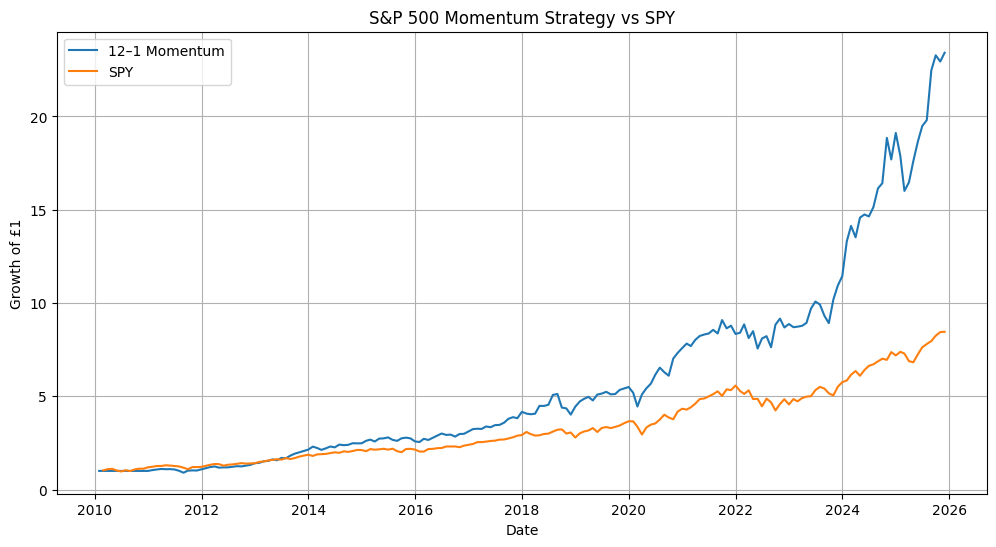

In [131]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_wealth.index,
    strategy_wealth,
    label="12–1 Momentum"
)

plt.plot(
    spy_wealth.index,
    spy_wealth,
    label="SPY"
)

plt.title("S&P 500 Momentum Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.grid(True)

plt.show()

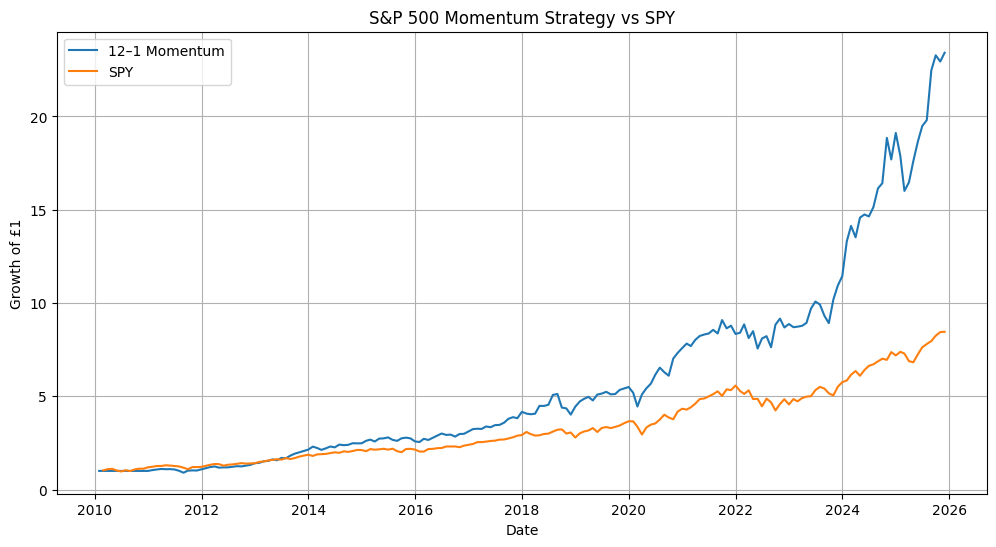

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_wealth.index,
    strategy_wealth,
    label="12–1 Momentum"
)

plt.plot(
    spy_wealth.index,
    spy_wealth,
    label="SPY"
)

plt.title("S&P 500 Momentum Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/equity_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [133]:
strategy_drawdown = (
    strategy_wealth
    / strategy_wealth.cummax()
    - 1
)

spy_drawdown = (
    spy_wealth
    / spy_wealth.cummax()
    - 1
)

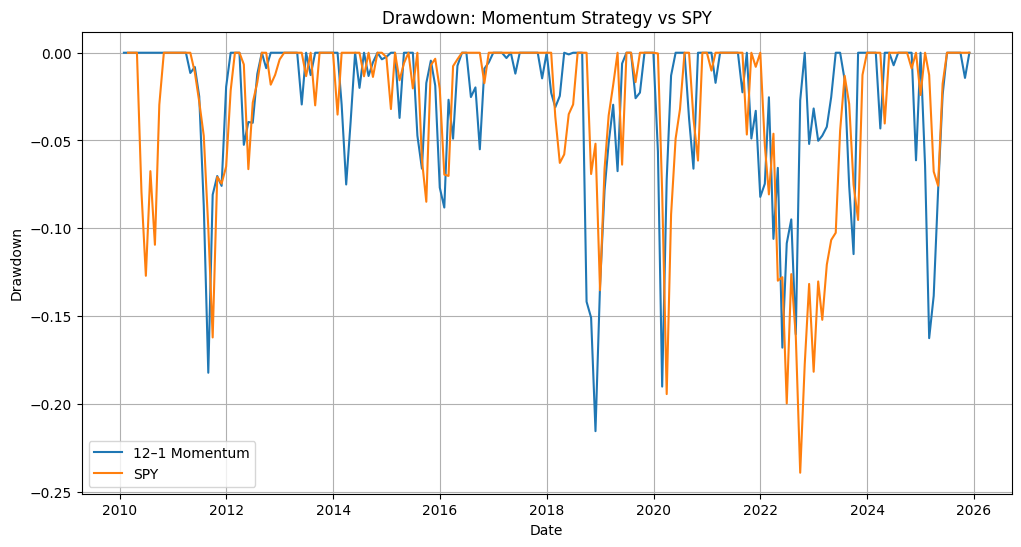

In [134]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_drawdown.index,
    strategy_drawdown,
    label="12–1 Momentum"
)

plt.plot(
    spy_drawdown.index,
    spy_drawdown,
    label="SPY"
)

plt.title("Drawdown: Momentum Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.show()

In [135]:
worst_drawdown_date = strategy_drawdown.idxmin()
worst_drawdown = strategy_drawdown.min()

print(f"Worst drawdown: {worst_drawdown:.2%}")
print(f"Date of worst drawdown: {worst_drawdown_date.date()}")

Worst drawdown: -21.56%
Date of worst drawdown: 2018-11-30


In [136]:
peak_date = strategy_wealth.loc[:worst_drawdown_date].idxmax()
peak_value = strategy_wealth.loc[:worst_drawdown_date].max()

print(f"Peak before worst drawdown: {peak_date.date()}")
print(f"Peak portfolio value: {peak_value:.2f}")
print(f"Trough date: {worst_drawdown_date.date()}")
print(f"Trough portfolio value: {strategy_wealth.loc[worst_drawdown_date]:.2f}")

Peak before worst drawdown: 2018-08-31
Peak portfolio value: 5.12
Trough date: 2018-11-30
Trough portfolio value: 4.02


In [137]:
recovery_date = strategy_wealth.loc[worst_drawdown_date:].loc[
    lambda x: x >= peak_value
].index

if len(recovery_date) > 0:
    print(f"Recovery date: {recovery_date[0].date()}")
else:
    print("Strategy had not recovered by the end of the backtest.")

Recovery date: 2019-06-30


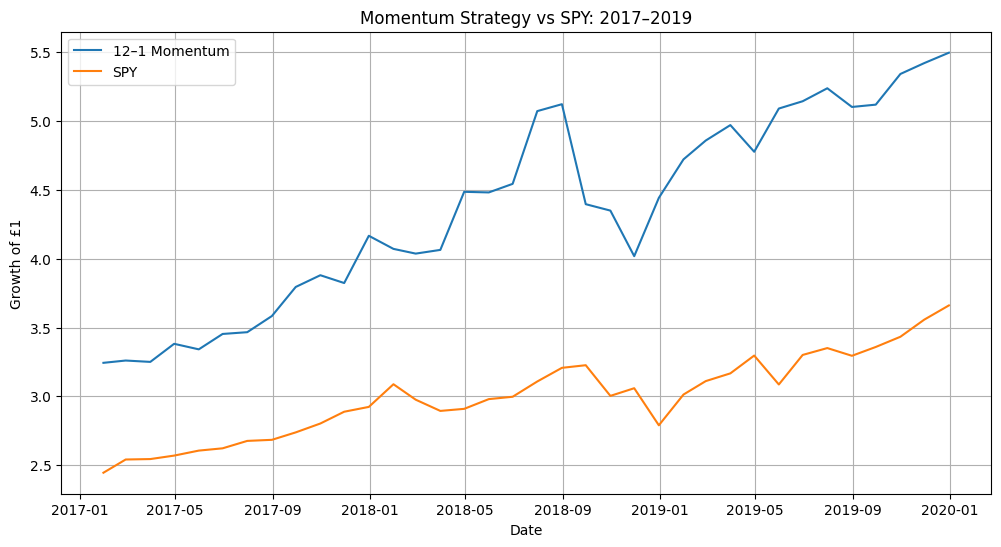

In [138]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_wealth.loc["2017-01-01":"2020-01-01"].index,
    strategy_wealth.loc["2017-01-01":"2020-01-01"],
    label="12–1 Momentum"
)

plt.plot(
    spy_wealth.loc["2017-01-01":"2020-01-01"].index,
    spy_wealth.loc["2017-01-01":"2020-01-01"],
    label="SPY"
)

plt.title("Momentum Strategy vs SPY: 2017–2019")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.grid(True)

plt.show()

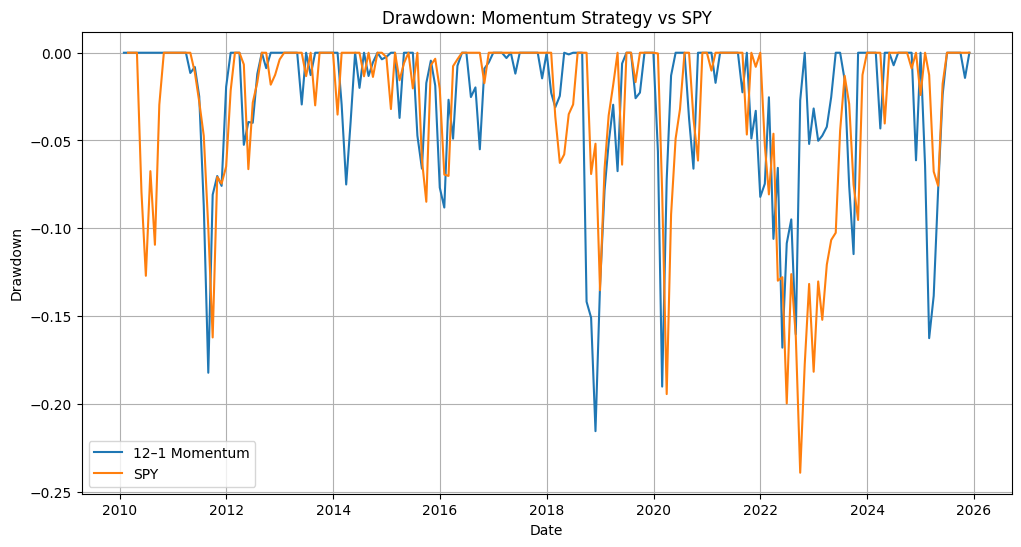

In [139]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_drawdown.index,
    strategy_drawdown,
    label="12–1 Momentum"
)

plt.plot(
    spy_drawdown.index,
    spy_drawdown,
    label="SPY"
)

plt.title("Drawdown: Momentum Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [140]:
momentum_6_1 = calculate_momentum(
    monthly_prices,
    lookback=6,
    skip=1
)

selected_6_1 = select_top_stocks(
    momentum_6_1,
    top_pct=0.10
)

weights_6_1 = calculate_weights(selected_6_1)

returns_6_1 = src.backtest.calculate_strategy_returns(
    weights_6_1,
    monthly_prices.pct_change()
)

returns_6_1 = returns_6_1.dropna()

print("6–1 Momentum Results")
print("--------------------")
print(f"CAGR: {calculate_cagr(returns_6_1):.2%}")
print(f"Volatility: {calculate_annualized_volatility(returns_6_1):.2%}")
print(f"Sharpe Ratio: {calculate_sharpe_ratio(returns_6_1):.2f}")
print(f"Max Drawdown: {calculate_max_drawdown(returns_6_1):.2%}")

6–1 Momentum Results
--------------------
CAGR: 24.39%
Volatility: 18.49%
Sharpe Ratio: 1.28
Max Drawdown: -21.87%


/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/149686775.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_prices.pct_change()


In [141]:
momentum_12_2 = calculate_momentum(
    monthly_prices,
    lookback=12,
    skip=2
)

selected_12_2 = select_top_stocks(
    momentum_12_2,
    top_pct=0.10
)

weights_12_2 = calculate_weights(selected_12_2)

returns_12_2 = src.backtest.calculate_strategy_returns(
    weights_12_2,
    monthly_prices.pct_change()
)

returns_12_2 = returns_12_2.dropna()

print("12–2 Momentum Results")
print("---------------------")
print(f"CAGR: {calculate_cagr(returns_12_2):.2%}")
print(f"Volatility: {calculate_annualized_volatility(returns_12_2):.2%}")
print(f"Sharpe Ratio: {calculate_sharpe_ratio(returns_12_2):.2f}")
print(f"Max Drawdown: {calculate_max_drawdown(returns_12_2):.2%}")

12–2 Momentum Results
---------------------
CAGR: 22.94%
Volatility: 18.11%
Sharpe Ratio: 1.23
Max Drawdown: -21.09%


/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/3225440542.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_prices.pct_change()


In [142]:
momentum_12_1_20 = calculate_momentum(
    monthly_prices,
    lookback=12,
    skip=1
)

selected_12_1_20 = select_top_stocks(
    momentum_12_1_20,
    top_pct=0.20
)

weights_12_1_20 = calculate_weights(selected_12_1_20)

returns_12_1_20 = src.backtest.calculate_strategy_returns(
    weights_12_1_20,
    monthly_prices.pct_change()
)

returns_12_1_20 = returns_12_1_20.dropna()

print("12–1 Momentum, Top 20% Results")
print("-------------------------------")
print(f"CAGR: {calculate_cagr(returns_12_1_20):.2%}")
print(f"Volatility: {calculate_annualized_volatility(returns_12_1_20):.2%}")
print(f"Sharpe Ratio: {calculate_sharpe_ratio(returns_12_1_20):.2f}")
print(f"Max Drawdown: {calculate_max_drawdown(returns_12_1_20):.2%}")

12–1 Momentum, Top 20% Results
-------------------------------
CAGR: 18.86%
Volatility: 15.75%
Sharpe Ratio: 1.18
Max Drawdown: -21.04%


/var/folders/v4/9wngy65x7qs18w1s2tfn1fcw0000gn/T/ipykernel_11420/2076094993.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_prices.pct_change()


In [143]:
robustness_results = pd.DataFrame({
    "CAGR": [
        calculate_cagr(returns_6_1),
        calculate_cagr(test_strategy_returns),
        calculate_cagr(returns_12_2),
        calculate_cagr(returns_12_1_20),
        spy_cagr
    ],
    "Volatility": [
        calculate_annualized_volatility(returns_6_1),
        calculate_annualized_volatility(test_strategy_returns),
        calculate_annualized_volatility(returns_12_2),
        calculate_annualized_volatility(returns_12_1_20),
        spy_volatility
    ],
    "Sharpe": [
        calculate_sharpe_ratio(returns_6_1),
        calculate_sharpe_ratio(test_strategy_returns),
        calculate_sharpe_ratio(returns_12_2),
        calculate_sharpe_ratio(returns_12_1_20),
        spy_sharpe
    ],
    "Max Drawdown": [
        calculate_max_drawdown(returns_6_1),
        calculate_max_drawdown(test_strategy_returns),
        calculate_max_drawdown(returns_12_2),
        calculate_max_drawdown(returns_12_1_20),
        calculate_max_drawdown(spy_aligned)
    ]
}, index=[
    "6–1 Top 10%",
    "12–1 Top 10%",
    "12–2 Top 10%",
    "12–1 Top 20%",
    "SPY"
])

robustness_results.to_csv(
    "../results/robustness_results.csv"
)

robustness_results

,CAGR,Volatility,Sharpe,Max Drawdown
6–1 Top 10%,0.243861,0.184943,1.275742,-0.218690
12–1 Top 10%,0.220416,0.179252,1.202319,-0.215597
12–2 Top 10%,0.229377,0.181095,1.232555,-0.210883
12–1 Top 20%,0.188638,0.157533,1.176629,-0.210361
SPY,0.144384,0.143595,1.015830,-0.239272


In [144]:
turnover = weights.diff().abs().sum(axis=1) / 2

turnover = turnover.dropna()

print("Average monthly turnover:", f"{turnover.mean():.2%}")
print("Annualized turnover:", f"{turnover.mean() * 12:.2%}")

Average monthly turnover: 25.95%
Annualized turnover: 311.43%


In [145]:
transaction_costs = [0, 0.0005, 0.001, 0.002, 0.005]

transaction_cost_results = []

for cost in transaction_costs:

    costs = turnover * cost

    costs = costs.reindex(test_strategy_returns.index).fillna(0)

    net_returns = test_strategy_returns - costs

    transaction_cost_results.append({
        "Transaction Cost": cost,
        "CAGR": calculate_cagr(net_returns),
        "Volatility": calculate_annualized_volatility(net_returns),
        "Sharpe": calculate_sharpe_ratio(net_returns),
        "Max Drawdown": calculate_max_drawdown(net_returns)
    })

transaction_cost_results = pd.DataFrame(
    transaction_cost_results
)

transaction_cost_results

,Transaction Cost,CAGR,Volatility,Sharpe,Max Drawdown
0,0.0000,0.220416,0.179252,1.202319,-0.215597
1,0.0005,0.218531,0.179264,1.193547,-0.216001
2,0.0010,0.216649,0.179276,1.184776,-0.216404
3,0.0020,0.212894,0.179300,1.167233,-0.217212
4,0.0050,0.201689,0.179377,1.114610,-0.219630


In [146]:
transaction_cost_results.to_csv(
    "../results/transaction_cost_sensitivity.csv",
    index=False
)

In [147]:
peak_date = strategy_wealth.loc[:worst_drawdown_date].idxmax()

portfolio_at_peak = weights.loc[peak_date]

portfolio_at_peak = (
    portfolio_at_peak[portfolio_at_peak > 0]
    .sort_values(ascending=False)
)

print("Peak date:", peak_date)
print()
print("Holdings at peak:")
print(portfolio_at_peak)

Peak date: 2018-08-31 00:00:00

Holdings at peak:
Ticker
ADBE    0.021277
PANW    0.021277
MOS     0.021277
MPC     0.021277
MU      0.021277
NFLX    0.021277
NOW     0.021277
NTAP    0.021277
ODFL    0.021277
ORLY    0.021277
OXY     0.021277
PSX     0.021277
LULU    0.021277
PTC     0.021277
RL      0.021277
ROST    0.021277
STX     0.021277
TGT     0.021277
TKO     0.021277
TPL     0.021277
VLO     0.021277
WAB     0.021277
MA      0.021277
KKR     0.021277
AKAM    0.021277
CVNA    0.021277
ALGN    0.021277
AMZN    0.021277
AXON    0.021277
BA      0.021277
CF      0.021277
COP     0.021277
CPAY    0.021277
CPRT    0.021277
CTAS    0.021277
DECK    0.021277
KDP     0.021277
EOG     0.021277
FIX     0.021277
FTNT    0.021277
GDDY    0.021277
GWW     0.021277
HCA     0.021277
IDXX    0.021277
ILMN    0.021277
ISRG    0.021277
XYZ     0.021277
Name: 2018-08-31 00:00:00, dtype: float64


In [149]:
sector_map = (
    sp500
    .assign(Symbol=sp500["Symbol"].str.replace(".", "-", regex=False))
    .set_index("Symbol")["GICS Sector"]
)

peak_sectors = portfolio_at_peak.rename("Weight").to_frame()

peak_sectors["Sector"] = peak_sectors.index.map(sector_map)

sector_exposure = (
    peak_sectors
    .groupby("Sector")["Weight"]
    .sum()
    .sort_values(ascending=False)
)

print("Sector exposure at portfolio peak:")
print(sector_exposure)

Sector exposure at portfolio peak:
Sector
Information Technology    0.212766
Industrials               0.170213
Consumer Discretionary    0.148936
Energy                    0.148936
Health Care               0.106383
Financials                0.085106
Communication Services    0.042553
Consumer Staples          0.042553
Materials                 0.042553
Name: Weight, dtype: float64


In [150]:
peak_date = pd.Timestamp("2018-08-31")
trough_date = pd.Timestamp("2018-11-30")

peak_weights = weights.loc[peak_date]
peak_weights = peak_weights[peak_weights > 0]

stock_returns_drawdown = (
    monthly_prices.loc[trough_date]
    / monthly_prices.loc[peak_date]
    - 1
)

contributions = (
    peak_weights * stock_returns_drawdown
).dropna()

contributions = contributions.sort_values()

print("Largest negative contributors:")
print(contributions.head(10))

print("\nLargest positive contributors:")
print(contributions.tail(10))

Largest negative contributors:
Ticker
ALGN   -0.008621
AXON   -0.007727
CVNA   -0.007049
VLO    -0.006716
TPL    -0.006511
MU     -0.005655
PANW   -0.005357
NTAP   -0.004810
NFLX   -0.004719
XYZ    -0.004513
dtype: float64

Largest positive contributors:
Ticker
NOW    -0.001202
ISRG   -0.001107
ILMN   -0.001039
ADBE   -0.001019
BA      0.000346
ORLY    0.000721
HCA     0.001623
DECK    0.001991
MOS     0.003238
KDP     0.004086
dtype: float64


In [151]:
momentum_drawdown_return = (
    strategy_wealth.loc[trough_date]
    / strategy_wealth.loc[peak_date]
    - 1
)

spy_drawdown_return = (
    spy_wealth.loc[trough_date]
    / spy_wealth.loc[peak_date]
    - 1
)

print("2018 Drawdown Period")
print("--------------------")
print(f"Momentum: {momentum_drawdown_return:.2%}")
print(f"SPY:      {spy_drawdown_return:.2%}")

2018 Drawdown Period
--------------------
Momentum: -21.56%
SPY:      -4.62%


In [152]:
momentum_at_peak = momentum.loc[peak_date]

analysis_2018 = pd.DataFrame({
    "Momentum": momentum_at_peak,
    "Return_Aug_to_Nov": stock_returns_drawdown,
    "Weight": peak_weights
}).dropna()

analysis_2018 = analysis_2018.loc[
    analysis_2018["Weight"] > 0
]

print(analysis_2018.sort_values("Momentum", ascending=False).head(15))

        Momentum  Return_Aug_to_Nov    Weight
Ticker                                       
TKO     2.681496          -0.152692  0.021277
AXON    2.128973          -0.363170  0.021277
XYZ     1.476063          -0.212094  0.021277
CVNA    1.408964          -0.331325  0.021277
GWW     1.165566          -0.108963  0.021277
LULU    1.084275          -0.144452  0.021277
NTAP    1.038397          -0.226088  0.021277
ALGN    1.017936          -0.405185  0.021277
NFLX    0.931486          -0.221796  0.021277
TPL     0.846061          -0.306035  0.021277
AMZN    0.812605          -0.160252  0.021277
VLO     0.781022          -0.315671  0.021277
DECK    0.765728           0.093565  0.021277
STX     0.763178          -0.184464  0.021277
CPRT    0.755583          -0.204167  0.021277


In [153]:

correlation = analysis_2018[
    ["Momentum", "Return_Aug_to_Nov"]
].corr().iloc[0, 1]

print(
    f"Correlation between prior momentum and subsequent return: "
    f"{correlation:.3f}"
)

Correlation between prior momentum and subsequent return: -0.373
